**Total Revenue Loss**

Revenue Loss = (room rate(ADR)* number of cancelled) + no-show bookings

In [1]:
import pandas as pd

In [42]:
# Load the train dataset
df = pd.read_csv('/content/drive/MyDrive/Data Science Life Cycle/Hotel_A_Train_Cleaned (1).csv')
df

,Reservation-id,Age,Expected_checkin,Expected_checkout,Booking_date,Adults,Children,Babies,Reservation_Status,Discount_Rate,...,Meal_Type_FB,Meal_Type_HB,Visted_Previously_YES,Previous_Cancellations_YES,Deposit_type_NON-REFUNDABLE,Deposit_type_REFUNDABLE,Booking_channel_DIRECT,Booking_channel_ONLINE,Required_Car_Parking_YES,Use_Promotion_YES
0,39428300,40,2015-07-01,2015-07-02,2015-05-21,2,2,0,1,10,...,False,False,False,False,False,False,False,True,True,True
1,77491756,49,2015-07-01,2015-07-02,2015-05-26,3,3,0,1,0,...,False,False,False,False,False,True,False,True,True,False
2,73747291,42,2015-07-02,2015-07-06,2015-06-29,3,3,0,1,0,...,False,False,False,False,False,False,False,True,True,False
3,67301739,25,2015-07-02,2015-07-03,2015-06-20,4,3,0,1,5,...,False,False,False,False,False,True,False,False,True,True
4,77222321,62,2015-07-03,2015-07-04,2015-06-20,1,1,0,1,10,...,False,False,False,False,False,False,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26984,15645505,49,2016-08-31,2016-09-01,2016-07-25,1,2,1,1,10,...,False,True,True,True,False,False,False,True,True,True
26985,56414525,49,2016-08-31,2016-09-01,2016-04-26,2,1,0,3,40,...,False,False,False,False,False,True,False,False,True,True
26986,52023375,49,2016-09-01,2016-09-02,2016-08-23,2,1,1,1,5,...,False,True,False,False,False,False,True,False,True,True
26987,98041387,65,2016-08-31,2016-09-01,2016-05-25,3,2,0,2,20,...,True,False,False,False,False,False,False,True,False,True


In [3]:
# Filter cancelled + no-show
cancelled_df = df[df['Reservation_Status'].isin([2, 3])]

# Calculate revenue loss
total_revenue_loss = cancelled_df['Room_Rate'].sum()

print("Total Revenue Loss: $", total_revenue_loss)

Total Revenue Loss: $ 1089430


**Revenue Loss by Age, Country, Region**

A) Revenue Loss by Age Group



In [4]:
df['age_group'] = pd.cut(df['Age'],
                         bins=[18,30,45,70],
                         labels=['18-30','30-45','45-70'])

In [5]:
# Add 'age_group' to cancelled_df if it's missing, by mapping from df
if 'age_group' not in cancelled_df.columns:
    # It's important to make a copy to avoid SettingWithCopyWarning
    # and ensure modifications are made on a standalone DataFrame.
    cancelled_df = cancelled_df.copy()
    cancelled_df['age_group'] = df['age_group'].loc[cancelled_df.index]

age_loss = cancelled_df.groupby('age_group', observed=False)['Room_Rate'].sum().reset_index()
print(age_loss)

  age_group  Room_Rate
0     18-30     251827
1     30-45     310167
2     45-70     512109


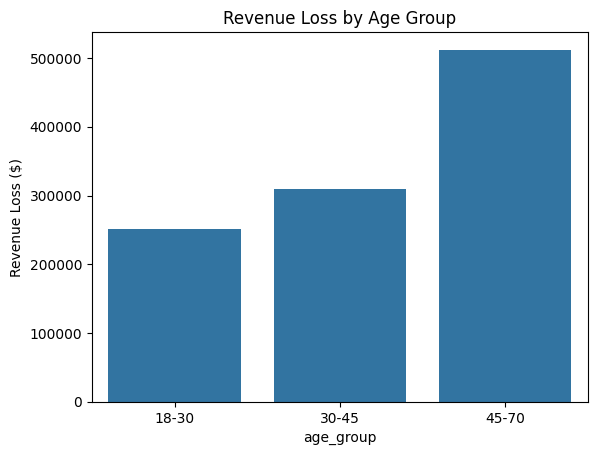

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(data=age_loss, x='age_group', y='Room_Rate')
plt.title("Revenue Loss by Age Group")
plt.ylabel("Revenue Loss ($)")
plt.show()

B) Revenue Loss by Day

In [7]:
import pandas as pd
# Load the train dataset
df = pd.read_csv('/content/drive/MyDrive/Data Science Life Cycle/Hotel_A_Train_Cleaned (1).csv')

df['Day_Type'] = df['Is_Weekend'].map({
    True: 'Weekend',
    False: 'Weekday'
})

In [8]:
loss_df = df[df['Reservation_Status'].isin([2,3])].copy()
loss_df['Day_Type'] = loss_df['Is_Weekend'].astype(int).map({
    1: 'Weekend',
    0: 'Weekday'
})

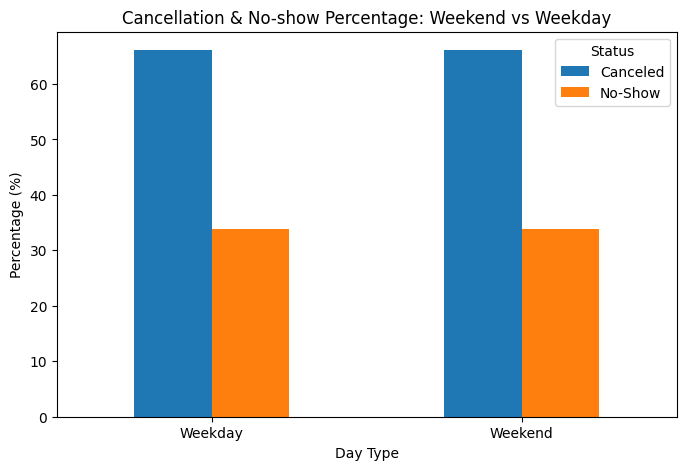

In [13]:
import matplotlib.pyplot as plt

# Ensure 'Status_Label' is available in loss_df
# It was created in df and needs to be mapped to loss_df for consistency.
if 'Status_Label' not in loss_df.columns:
    loss_df['Status_Label'] = df['Status_Label'].loc[loss_df.index]

# Calculate day_pct for cancellation and no-show percentages
day_pct = pd.crosstab(
    loss_df['Day_Type'],
    loss_df['Status_Label'],
    normalize='index'
) * 100

# Plot
day_pct[['Canceled', 'No-Show']].plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Cancellation & No-show Percentage: Weekend vs Weekday')
plt.ylabel('Percentage (%)')
plt.xlabel('Day Type')
plt.xticks(rotation=0)
plt.legend(title='Status')
plt.show()

In [ ]:
avg_loss = cancelled_df["Room_Rate"].mean()
print("Average Revenue Loss:", avg_loss)

Average Revenue Loss: 175.29042638777153


In [ ]:
df['is_cancelled'] = df['Reservation_Status'].isin([2])
weekend_cancel = df.groupby('Is_Weekend')['is_cancelled'].mean() * 100
print(weekend_cancel)

Is_Weekend
0    14.358899
1    17.837919
Name: is_cancelled, dtype: float64


C) Revenue Loss by lead time

In [43]:
max_lead = df['Lead_Time'].max()
print("Highest Lead Time:", max_lead)

Highest Lead Time: 708


In [44]:
df[df['Lead_Time'] == df['Lead_Time'].max()]

,Reservation-id,Age,Expected_checkin,Expected_checkout,Booking_date,Adults,Children,Babies,Reservation_Status,Discount_Rate,...,Meal_Type_FB,Meal_Type_HB,Visted_Previously_YES,Previous_Cancellations_YES,Deposit_type_NON-REFUNDABLE,Deposit_type_REFUNDABLE,Booking_channel_DIRECT,Booking_channel_ONLINE,Required_Car_Parking_YES,Use_Promotion_YES
3921,81524080,65,2016-03-24,2016-03-25,2014-04-16,5,1,0,1,25,...,False,True,False,False,False,False,False,True,True,True


In [45]:
bins = [0, 14, 60, 708]
labels = ['Short', 'Medium', 'Long']

df['Lead_Time_Group'] = pd.cut(df['Lead_Time'],
                              bins=bins,
                              labels=labels,
                              include_lowest=True)

In [46]:
df['Lead_Time_Group'].value_counts()

,count
Lead_Time_Group,
Long,18662
Medium,6234
Short,2093


In [49]:
lead_time_loss = loss_df.groupby(['Lead_Time_Group', 'Reservation_Status'])['Room_Rate'] \
       .sum().reset_index()
lead_time_loss['Status_Label'] = lead_time_loss['Reservation_Status'].map({
    2: 'Canceled',
    3: 'No-Show'
})


/tmp/ipykernel_522/3973911318.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  lead_time_loss = loss_df.groupby(['Lead_Time_Group', 'Reservation_Status'])['Room_Rate'] \


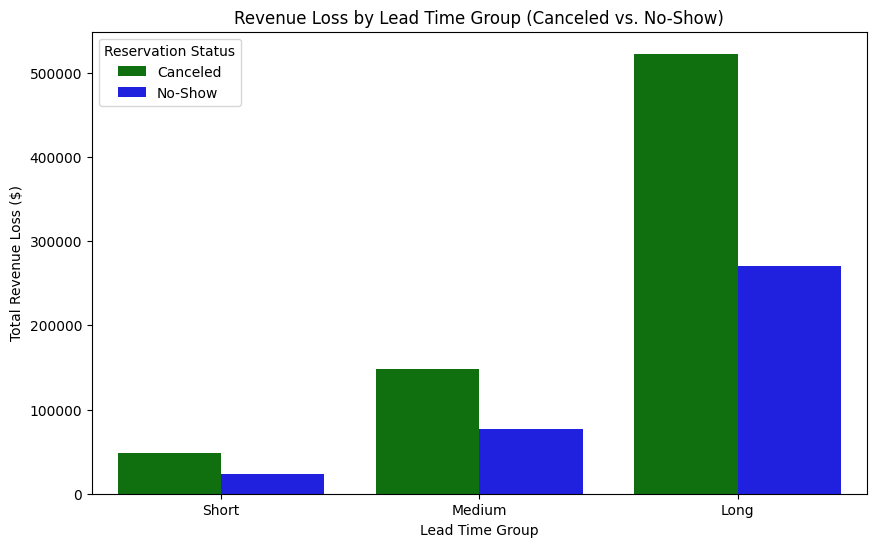

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(
    data=lead_time_loss,
    x='Lead_Time_Group',
    y='Room_Rate',
    hue='Status_Label',
    palette={'Canceled': 'green', 'No-Show': 'blue'},
    errorbar=None
)
plt.title('Revenue Loss by Lead Time Group (Canceled vs. No-Show)')
plt.xlabel('Lead Time Group')
plt.ylabel('Total Revenue Loss ($)')
plt.legend(title='Reservation Status')
plt.show()

Recommendations

I. Cancellation % using different factors

In [37]:
df['is_cancelled'] = df['Reservation_Status'].isin([2])
promo_cancel = df.groupby('Use_Promotion_YES')['is_cancelled'].mean() * 100
print(promo_cancel)

Use_Promotion_YES
False    15.175909
True     15.235935
Name: is_cancelled, dtype: float64


In [38]:
prev_cancel = df.groupby('Previous_Cancellations_YES')['is_cancelled'].mean() * 100
print(prev_cancel)

Previous_Cancellations_YES
False    15.334782
True     14.332354
Name: is_cancelled, dtype: float64


In [39]:
channel_cancel = df.groupby('Booking_channel_ONLINE')['is_cancelled'].mean() * 100
print(channel_cancel)

Booking_channel_ONLINE
False    15.223523
True     15.219097
Name: is_cancelled, dtype: float64


In [40]:
deposit_cancel = df.groupby('Deposit_type_NON-REFUNDABLE')['is_cancelled'].mean() * 100
print(deposit_cancel)

Deposit_type_NON-REFUNDABLE
False    15.236095
True     15.053763
Name: is_cancelled, dtype: float64


In [41]:
cancelled_df = df[df['Reservation_Status'].isin([3])]

total_loss = cancelled_df['Room_Rate'].sum()
print("Total Revenue Loss:", total_loss)

Total Revenue Loss: 370625


In [25]:
cancelled_df = df[df['Reservation_Status'].isin([2])]

total_loss = cancelled_df['Room_Rate'].sum()
print("Total Revenue Loss:", total_loss)

Total Revenue Loss: 718805


In [26]:
loss_df = df[df['Reservation_Status'].isin([2,3])].copy()

In [27]:
promo_loss = loss_df.groupby(['Is_Weekend', 'Reservation_Status'])['Room_Rate'] \
       .sum().reset_index()

In [28]:
df['Status_Label'] = df['Reservation_Status'].map({
    2: 'Canceled',
    3: 'No-Show'
})

In [30]:
loss_df['Status_Label'] = df['Status_Label'].loc[loss_df.index]
lead_pct = pd.crosstab(
    loss_df['Lead_Time_Group'],
    loss_df['Status_Label'],
    normalize='index'
) * 100

In [31]:
loss_df.groupby(['Lead_Time_Group', 'Reservation_Status'])['Room_Rate'] \
       .sum().reset_index()

/tmp/ipykernel_522/3909338190.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  loss_df.groupby(['Lead_Time_Group', 'Reservation_Status'])['Room_Rate'] \


,Lead_Time_Group,Reservation_Status,Room_Rate
0,Short,2,47973
1,Short,3,23067
2,Medium,2,148063
3,Medium,3,76627
4,Long,2,522769
5,Long,3,270931


In [32]:
loss_df.groupby(['Previous_Cancellations_YES', 'Reservation_Status'])['Room_Rate'] \
       .sum().reset_index()

,Previous_Cancellations_YES,Reservation_Status,Room_Rate
0,False,2,642372
1,False,3,329033
2,True,2,76433
3,True,3,41592


In [33]:
loss_df.groupby(['Booking_channel_ONLINE', 'Reservation_Status'])['Room_Rate'] \
       .sum().reset_index()

,Booking_channel_ONLINE,Reservation_Status,Room_Rate
0,False,2,309007
1,False,3,159921
2,True,2,409798
3,True,3,210704


In [34]:
loss_df.groupby(['Deposit_type_NON-REFUNDABLE', 'Reservation_Status'])['Room_Rate'] \
       .sum().reset_index()

,Deposit_type_NON-REFUNDABLE,Reservation_Status,Room_Rate
0,False,2,660636
1,False,3,339176
2,True,2,58169
3,True,3,31449


In [35]:
high_risk_avg = cancelled_df['Room_Rate'].mean()

deposit = high_risk_avg * 0.3   # 30%
print(deposit)

52.493062317429406
